In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('diabetes_data.csv')
df.head(5)

,user_id,date,weight,height,blood_glucose,physical_activity,diet,medication_adherence,stress_level,sleep_hours,hydration_level,bmi,risk_score
0,1,2021-01-01,77.450712,183.993554,112.992869,0.000000,1,0,1,6.342317,1,22.9,38.000000
1,2,2021-01-02,67.926035,179.246337,134.219253,12.792300,0,1,2,10.658122,1,21.1,39.162310
2,3,2021-01-03,79.715328,170.596304,108.303203,21.727889,1,1,0,5.997832,1,27.4,31.481633
3,4,2021-01-04,92.845448,163.530632,127.681539,67.753753,1,0,1,7.958814,1,34.7,45.000000
4,5,2021-01-05,66.487699,176.982233,70.000000,41.131062,1,1,0,6.774707,1,21.2,4.717234


In [3]:
df.info()
print('---------------------------')
df.describe()
print('---------------------------')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1000 non-null   int64  
 1   date                  1000 non-null   object 
 2   weight                1000 non-null   float64
 3   height                1000 non-null   float64
 4   blood_glucose         1000 non-null   float64
 5   physical_activity     1000 non-null   float64
 6   diet                  1000 non-null   int64  
 7   medication_adherence  1000 non-null   int64  
 8   stress_level          1000 non-null   int64  
 9   sleep_hours           1000 non-null   float64
 10  hydration_level       1000 non-null   int64  
 11  bmi                   1000 non-null   float64
 12  risk_score            1000 non-null   float64
dtypes: float64(7), int64(5), object(1)
memory usage: 101.7+ KB
---------------------------
---------------------------


user_id                 0
date                    0
weight                  0
height                  0
blood_glucose           0
physical_activity       0
diet                    0
medication_adherence    0
stress_level            0
sleep_hours             0
hydration_level         0
bmi                     0
risk_score              0
dtype: int64

In [4]:
df.drop('date',axis=1,inplace=True)

In [5]:
X=df.drop(columns=['user_id','risk_score'],axis=1)
Y=df['risk_score']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2, random_state=42)

In [7]:
Random=RandomForestRegressor()
Gradient=GradientBoostingRegressor()

In [8]:
model1=Random.fit(x_train,y_train)
model2=Gradient.fit(x_train,y_train)

In [9]:
y_pred1=Random.predict(x_test)
y_pred2=Gradient.predict(x_test)

In [10]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [11]:
print("Random Forest R2 Score:",r2_score(y_test,y_pred1))
print("Gradient Boosting R2 Score:",r2_score(y_test,y_pred2))


Random Forest R2 Score: 0.9043600590958158
Gradient Boosting R2 Score: 0.9786640561761663


In [12]:
random_score=cross_val_score(Random,x_train,y_train,cv=5)
gradient_score=cross_val_score(Gradient,x_train,y_train,cv=5)
print("Random Forest Cross Val Score:",random_score.mean())
print("Gradient Boosting Cross Val Score:",gradient_score.mean())

Random Forest Cross Val Score: 0.8924459496969408
Gradient Boosting Cross Val Score: 0.9754558783379526


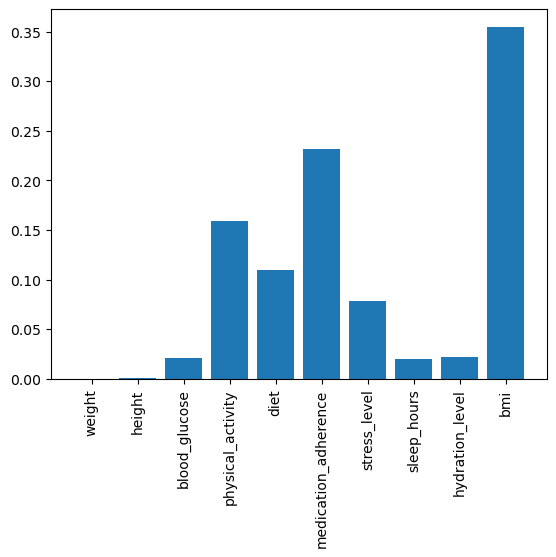

In [13]:
import matplotlib.pyplot as plt

importance = Gradient.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.show()

In [14]:
importance = Gradient.feature_importances_
importance

array([0.00048407, 0.00055973, 0.02147815, 0.15948726, 0.10978217,
       0.23218686, 0.07901144, 0.01995158, 0.02252416, 0.35453459])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_dict={
    'n_estimators':[50,100,150],
    'learning_rate':[0.01,0.5,0.1],
    'max_depth':[4,5,6]
}
search=RandomizedSearchCV(
    Gradient,
    param_dict,
    n_iter=10,
    cv=5,
    scoring='r2',random_state=42,
    n_jobs=-1
    
    
)
best_fit=search.fit(x_train,y_train)
print("best prameters:",best_fit.best_params_)

In [ ]:
new_gradient=GradientBoostingRegressor(n_estimators= 50, max_depth=4, learning_rate= 0.5)
new_model=new_gradient.fit(x_train,y_train)
new_gradient_cross=cross_val_score(new_gradient,x_train,y_train,cv=5)
print("New Gradient Cross Val Score after Best Parameters:",new_gradient_cross.mean())


In [ ]:
import pandas as pd

new_data = pd.DataFrame({
    'weight':[70],
    'height':[175],
    'blood_glucose':[120],
    'physical_activity':[3],
    'diet':[2],
    'medication_adherence':[1],
    'stress_level':[4],
    'sleep_hours':[7],
    'hydration_level':[2.5],
    'bmi':[22]
})

prediction=Gradient.predict(new_data)
print("Prediction of Risk of Diabetes:",prediction)

In [ ]:
import joblib

joblib.dump(Gradient, "diabetes_model.pkl")